# Step 3 - Implicit Method for European Options

We solve the Black-Scholes PDE using a **fully implicit** finite difference scheme and compare against the closed-form formula.

In [8]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from src.solvers.implicit import solve_implicit
from src.black_scholes import bs_call_price, bs_put_price

## Parameters

In [9]:
K     = 100    # strike
r     = 0.05   # risk-free rate
sigma = 0.20   # volatility
T     = 1.0    # time to expiry (years)
S_max = 3 * K  # upper boundary for stock price

M = 200   # stock grid points
N = 200   # time steps

## Solve - European Call

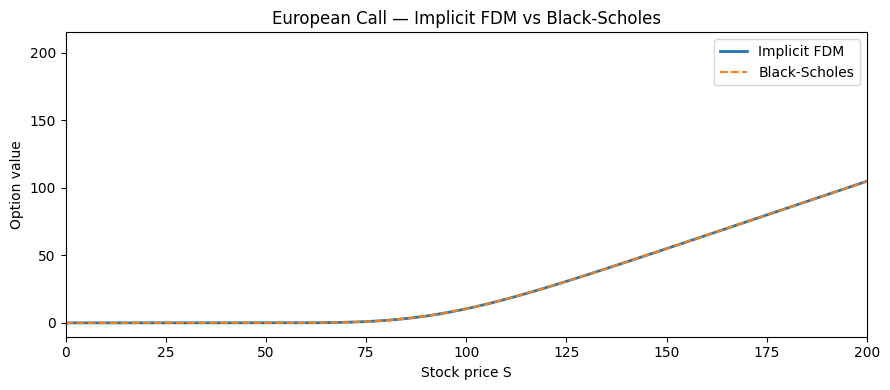

In [10]:
S, V_call = solve_implicit(S_max, K, r, sigma, T, M, N, option_type='call')

# Closed-form benchmark
bs_call = np.array([bs_call_price(s, K, r, sigma, T) for s in S])

plt.figure(figsize=(9, 4))
plt.plot(S, V_call, label='Implicit FDM', lw=2)
plt.plot(S, bs_call, '--', label='Black-Scholes', lw=1.5)
plt.xlim(0, 200)
plt.xlabel('Stock price S')
plt.ylabel('Option value')
plt.title('European Call — Implicit FDM vs Black-Scholes')
plt.legend()
plt.tight_layout()
plt.show()

## Solve - European Put

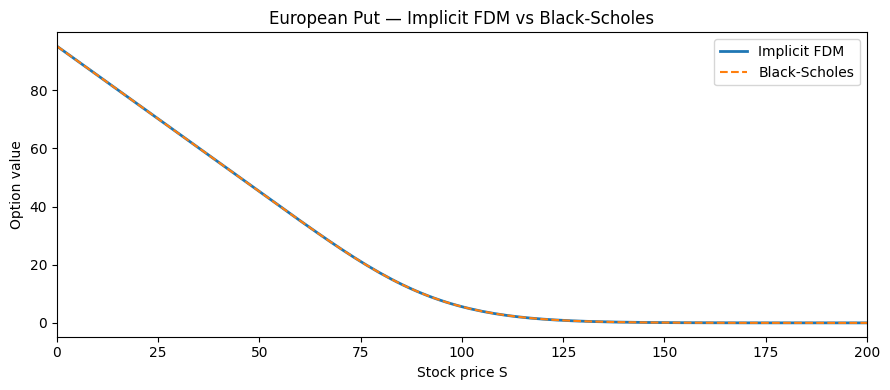

In [11]:
S, V_put = solve_implicit(S_max, K, r, sigma, T, M, N, option_type='put')

bs_put = np.array([bs_put_price(s, K, r, sigma, T) for s in S])

plt.figure(figsize=(9, 4))
plt.plot(S, V_put, label='Implicit FDM', lw=2)
plt.plot(S, bs_put, '--', label='Black-Scholes', lw=1.5)
plt.xlim(0, 200)
plt.xlabel('Stock price S')
plt.ylabel('Option value')
plt.title('European Put — Implicit FDM vs Black-Scholes')
plt.legend()
plt.tight_layout()
plt.show()

## Point Validation at S = K = 100

In [12]:
S0 = 100.0

fdm_call = np.interp(S0, S, V_call)
fdm_put  = np.interp(S0, S, V_put)
exact_call = bs_call_price(S0, K, r, sigma, T)
exact_put  = bs_put_price(S0, K, r, sigma, T)

print(f"{'':12s} {'FDM':>10s} {'Exact':>10s} {'Error':>10s}")
print(f"{'Call':12s} {fdm_call:10.4f} {exact_call:10.4f} {abs(fdm_call - exact_call):10.6f}")
print(f"{'Put':12s} {fdm_put:10.4f}  {exact_put:10.4f} {abs(fdm_put - exact_put):10.6f}")

                    FDM      Exact      Error
Call            10.4492    10.4506   0.001388
Put              5.5727      5.5735   0.000793


## Convergence - Error vs Grid Size

Refine the grid and observe that the error shrinks (first-order in both dS and dt for the implicit method).

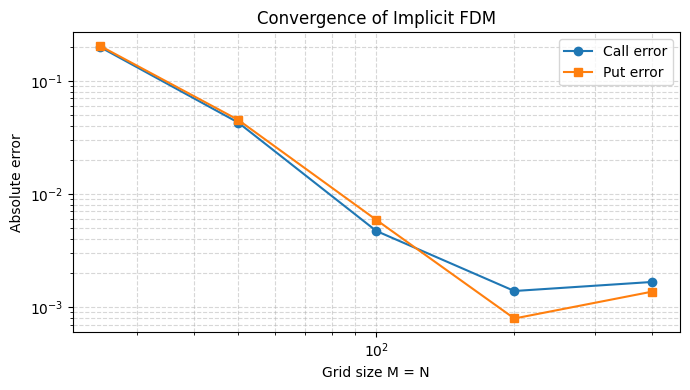

In [13]:
grid_sizes = [25, 50, 100, 200, 400]
errors_call = []
errors_put  = []
exact_call0 = bs_call_price(S0, K, r, sigma, T)
exact_put0  = bs_put_price(S0, K, r, sigma, T)

for n in grid_sizes:
    Sc, Vc = solve_implicit(S_max, K, r, sigma, T, M=n, N=n, option_type='call')
    Sp, Vp = solve_implicit(S_max, K, r, sigma, T, M=n, N=n, option_type='put')
    errors_call.append(abs(np.interp(S0, Sc, Vc) - exact_call0))
    errors_put.append(abs(np.interp(S0, Sp, Vp) - exact_put0))

plt.figure(figsize=(7, 4))
plt.loglog(grid_sizes, errors_call, 'o-', label='Call error')
plt.loglog(grid_sizes, errors_put,  's-', label='Put error')
plt.xlabel('Grid size M = N')
plt.ylabel('Absolute error')
plt.title('Convergence of Implicit FDM')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()